In [13]:
DATASET_PATH = "/kaggle/input/medical-waste"
WORKING_DIR  = "/kaggle/working/yolo_working"
SAVE_DIR     = "/kaggle/working/yolo_models"

import os
os.makedirs(WORKING_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Dataset : {DATASET_PATH}")
print(f"Working : {WORKING_DIR}")
print(f"Save dir: {SAVE_DIR}")


Dataset : /kaggle/input/medical-waste
Working : /kaggle/working/yolo_working
Save dir: /kaggle/working/yolo_models


In [15]:
!pip install -q ultralytics albumentations


In [16]:
import os
import random
import shutil
import uuid
import traceback
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import albumentations as A
import yaml
import torch
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from ultralytics import YOLO

# ── path aliases (used everywhere below) ──────────────────────────────────────
dataset_path   = Path(DATASET_PATH)
working_path   = Path(WORKING_DIR)
save_path      = Path(SAVE_DIR)
target_dataset = working_path / "medical_yolo_data"

print("Imports OK")
print("CUDA available:", torch.cuda.is_available())


Imports OK
CUDA available: True


In [4]:
classes = sorted([f.name for f in dataset_path.iterdir() if f.is_dir()])
print(f"Total Classes: {len(classes)}")
print(f"Class Names: {classes}")


Total Classes: 23
Class Names: ['body_tissue_or_organ', 'gauze', 'glass_equipment_packaging', 'glove_pair_latex', 'glove_pair_nitrile', 'glove_pair_surgery', 'glove_single_latex', 'glove_single_nitrile', 'glove_single_surgery', 'mask', 'medical_cap', 'medical_glasses', 'metal_equipment_packaging', 'organic_waste', 'paper_equipment_packaging', 'plastic_equipment_packaging', 'shoe_cover_pair', 'shoe_cover_single', 'syringe', 'syringe_needle', 'test_tube', 'tweezers', 'urine_bag']


In [17]:
data = {"Class": [], "Image Count": []}
for class_name in classes:
    class_dir = dataset_path / class_name
    image_count = len([f for f in class_dir.iterdir()
                       if f.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    data["Class"].append(class_name)
    data["Image Count"].append(image_count)

df = pd.DataFrame(data).sort_values(by="Image Count", ascending=False).reset_index(drop=True)
display(df)


,Class,Image Count
0,gauze,845
1,organic_waste,569
2,syringe_needle,563
3,syringe,535
4,tweezers,531
5,body_tissue_or_organ,515
6,paper_equipment_packaging,509
7,plastic_equipment_packaging,446
8,glass_equipment_packaging,440
9,mask,419


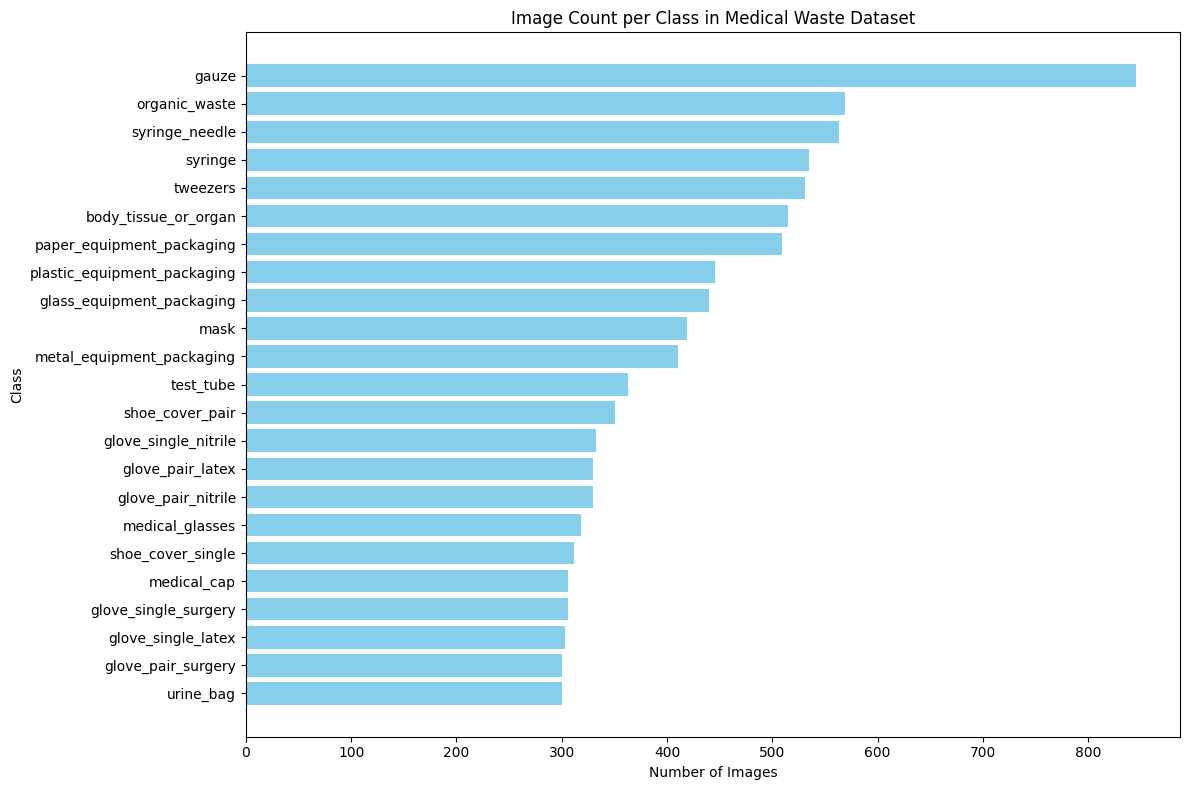

In [6]:
plt.figure(figsize=(12, 8))
plt.barh(df["Class"], df["Image Count"], color="skyblue")
plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.title("Image Count per Class in Medical Waste Dataset")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [7]:
def prepare_5fold_dataset(source_dir, target_dir, seed=42, oversample_limit="median", n_splits=5):
    source_dir = Path(source_dir)
    target_dir = Path(target_dir)
    random.seed(seed)

    aug = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
    ])

    class_labels = []
    image_paths  = []

    for class_dir in source_dir.iterdir():
        if class_dir.is_dir():
            images = (list(class_dir.glob("*.jpg")) +
                      list(class_dir.glob("*.jpeg")) +
                      list(class_dir.glob("*.png")))
            label = class_dir.name
            image_paths  += images
            class_labels += [label] * len(images)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for fold, (train_idx, val_idx) in enumerate(skf.split(image_paths, class_labels)):
        print(f"\nProcessing fold {fold + 1}...")
        fold_train_paths  = [image_paths[i]  for i in train_idx]
        fold_val_paths    = [image_paths[i]  for i in val_idx]
        fold_train_labels = [class_labels[i] for i in train_idx]
        fold_val_labels   = [class_labels[i] for i in val_idx]

        class_counts = defaultdict(int)
        for label in fold_train_labels:
            class_counts[label] += 1

        values = list(class_counts.values())
        if oversample_limit == "median":
            target_count = int(sorted(values)[len(values) // 2])
        elif isinstance(oversample_limit, int):
            target_count = oversample_limit
        else:
            raise ValueError("oversample_limit must be 'median' or an integer.")

        train_by_class = defaultdict(list)
        for path, label in zip(fold_train_paths, fold_train_labels):
            train_by_class[label].append(path)

        for label, images in train_by_class.items():
            save_dir = target_dir / f"fold_{fold}" / "train" / label
            save_dir.mkdir(parents=True, exist_ok=True)

            for img_path in images[:target_count]:
                new_name = f"{label}_{uuid.uuid4().hex}{img_path.suffix.lower()}"
                shutil.copy(img_path, save_dir / new_name)

            current_count = len(images)
            while current_count < target_count:
                img_path = random.choice(train_by_class[label])
                img = cv2.imread(str(img_path))
                if img is None:
                    continue
                try:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                except cv2.error:
                    continue
                augmented    = aug(image=img)["image"]
                aug_filename = f"{label}_{uuid.uuid4().hex}.jpg"
                cv2.imwrite(str(save_dir / aug_filename),
                            cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))
                current_count += 1

        for img_path, label in zip(fold_val_paths, fold_val_labels):
            save_dir = target_dir / f"fold_{fold}" / "val" / label
            save_dir.mkdir(parents=True, exist_ok=True)
            new_name = f"{label}_{uuid.uuid4().hex}{img_path.suffix.lower()}"
            shutil.copy(img_path, save_dir / new_name)

    print(f"\n 5-Fold datasets saved at: {target_dir}")


prepare_5fold_dataset(dataset_path, target_dataset)



Processing fold 1...

Processing fold 2...

Processing fold 3...

Processing fold 4...

Processing fold 5...

 5-Fold datasets saved at: /kaggle/working/yolo_working/medical_yolo_data


In [8]:
yaml_config = """
nc: 23
ch: 3

backbone:
  - [-1, 1, Conv, [32, 3, 2]]
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 3, Bottleneck, [64]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 3, Bottleneck, [128]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 1, SPPF, [256]]

head:
  - [-1, 1, Classify, [nc]]
"""

model_config_path = working_path / "yolov8n-cls.yaml"
with open(model_config_path, "w") as f:
    f.write(yaml_config)
print(f"Model config written to {model_config_path}")


Model config written to /kaggle/working/yolo_working/yolov8n-cls.yaml


In [9]:
try:
    class_names = sorted({p.name for p in dataset_path.glob("*") if p.is_dir()})
    num_classes  = len(class_names)
    if num_classes == 0:
        raise ValueError("No class directories found")
except Exception as e:
    print(f" {e} — using dummy class names")
    class_names = [f"class_{i}" for i in range(23)]
    num_classes  = 23

print(f"Detected {num_classes} classes: {class_names}")

yaml_dir = working_path
for fold in range(5):
    fold_path = target_dataset / f"fold_{fold}"
    yaml_dict = {
        "path" : str(fold_path),
        "train": "train",
        "val"  : "val",
        "nc"   : num_classes,
        "names": class_names,
    }
    yaml_path = yaml_dir / f"fold_{fold}.yaml"
    with open(yaml_path, "w") as f:
        yaml.dump(yaml_dict, f)
    print(f" Saved config: {yaml_path}")


Detected 23 classes: ['body_tissue_or_organ', 'gauze', 'glass_equipment_packaging', 'glove_pair_latex', 'glove_pair_nitrile', 'glove_pair_surgery', 'glove_single_latex', 'glove_single_nitrile', 'glove_single_surgery', 'mask', 'medical_cap', 'medical_glasses', 'metal_equipment_packaging', 'organic_waste', 'paper_equipment_packaging', 'plastic_equipment_packaging', 'shoe_cover_pair', 'shoe_cover_single', 'syringe', 'syringe_needle', 'test_tube', 'tweezers', 'urine_bag']
 Saved config: /kaggle/working/yolo_working/fold_0.yaml
 Saved config: /kaggle/working/yolo_working/fold_1.yaml
 Saved config: /kaggle/working/yolo_working/fold_2.yaml
 Saved config: /kaggle/working/yolo_working/fold_3.yaml
 Saved config: /kaggle/working/yolo_working/fold_4.yaml


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from ultralytics.data.dataset import ClassificationDataset  # noqa — kept for compatibility


In [ ]:
all_fold_metrics = {"precision": [], "recall": [], "f1_score": [], "accuracy": []}
fold_labels          = []
trained_model_paths  = []

for fold in range(5):
    print(f"\n Training Fold {fold}...")

    current_fold_data_path = target_dataset / f"fold_{fold}"
    val_data_path          = current_fold_data_path / "val"

    model   = YOLO(str(model_config_path))
    results = model.train(
        data     = str(current_fold_data_path),
        epochs   = 30,
        imgsz    = 224,
        pretrained = False,
        name     = f"fold_{fold}_run",
        project  = str(working_path / "runs"),   # keep runs inside WORKING_DIR
    )

    best_model_path = Path(results.save_dir) / "weights" / "best.pt"
    trained_model_paths.append(str(best_model_path))

    if not best_model_path.exists():
        print(f" best.pt NOT found for fold {fold}")
        current_precision = current_recall = current_f1_score = current_accuracy = float("nan")
    else:
        print(f" Validating fold {fold} from {best_model_path}")
        val_model = YOLO(str(best_model_path))

        try:
            val_results = val_model.val(data=str(val_data_path), imgsz=224, split="val")
            cm = val_results.confusion_matrix.matrix.astype(int)

            y_true_list, y_pred_list = [], []
            for true_class in range(cm.shape[0]):
                for pred_class in range(cm.shape[1]):
                    count = cm[true_class, pred_class]
                    y_true_list.extend([true_class] * count)
                    y_pred_list.extend([pred_class] * count)

            print(f"Total predictions: {len(y_true_list)}")
            current_precision = precision_score(y_true_list, y_pred_list, average="macro", zero_division=0)
            current_recall    = recall_score   (y_true_list, y_pred_list, average="macro", zero_division=0)
            current_f1_score  = f1_score       (y_true_list, y_pred_list, average="macro", zero_division=0)
            current_accuracy  = accuracy_score (y_true_list, y_pred_list)

        except Exception as e:
            print(f"Exception during metrics for fold {fold}: {e}")
            traceback.print_exc()
            current_precision = current_recall = current_f1_score = current_accuracy = float("nan")

    all_fold_metrics["precision"].append(current_precision)
    all_fold_metrics["recall"]   .append(current_recall)
    all_fold_metrics["f1_score"] .append(current_f1_score)
    all_fold_metrics["accuracy"] .append(current_accuracy)
    fold_labels.append(f"Fold_{fold}")

    print(f" Fold {fold} → Acc: {current_accuracy:.4f}  P: {current_precision:.4f}  R: {current_recall:.4f}  F1: {current_f1_score:.4f}")

print("\n All folds processed.")
df_folds = pd.DataFrame(all_fold_metrics, index=fold_labels)
print("\nSummary:")
display(df_folds)



 Training Fold 0...
YOLOv8n-cls summary: 44 layers, 1,467,895 parameters, 1,467,895 gradients, 16.1 GFLOPs
Ultralytics 8.4.26 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_working/medical_yolo_data/fold_0, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolo_working/yolov8n-cls.yaml

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all      0.933      0.954
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/yolo_working/runs/fold_0_run
 Validating fold 0 from /kaggle/working/yolo_working/runs/fold_0_run/weights/best.pt
Ultralytics 8.4.26 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 25 layers, 1,464,887 parameters, 0 gradients, 15.9 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /kaggle/working/yolo_working/medical_yolo_data/fold_0/val/train
Found 1562 images in subdirectories. Attempting to split...
Splitting /kaggle/working/yolo_working/medical_yolo_data/fold_0/val (23 classes, 1845 images) into 80% train, 20% val...
Split complete in /kaggle/working/yolo_working/medical_yolo_data/fold_0/val_split ✅
train: /kaggle/working/yolo_working/medical_yolo_data/fold_0/val_split/train... found 1465 images in 23 classes ✅ 
val: /kaggle/working/yolo_working/medical_yolo_data/fold_0/val_spli

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all      0.939      0.968
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val
Total predictions: 380
 Fold 0 → Acc: 0.9395  P: 0.9520  R: 0.9468  F1: 0.9452

 Training Fold 1...
YOLOv8n-cls summary: 44 layers, 1,467,895 parameters, 1,467,895 gradients, 16.1 GFLOPs
Ultralytics 8.4.26 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_working/medical_yolo_data/fold_1, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1

In [18]:
import shutil
for fold, model_path in enumerate(trained_model_paths):
    src = Path(model_path)
    if src.exists():
        dst = save_path / f"fold_{fold}_best.pt"
        shutil.copy(src, dst)
        print(f" Fold {fold} saved → {dst}")
    else:
        print(f" Fold {fold} best.pt not found at {src}")
print(f"\nAll models saved to: {save_path}")

 Fold 0 saved → /kaggle/working/yolo_models/fold_0_best.pt

All models saved to: /kaggle/working/yolo_models


In [20]:
import numpy as np

accuracies = all_fold_metrics["accuracy"]
best_fold  = int(np.nanargmax(accuracies))
best_pt    = save_path / f"fold_{best_fold}_best.pt"

print(f"Best fold: {best_fold}  (accuracy={accuracies[best_fold]:.4f})")
print(f"Exporting {best_pt} to ONNX...")

best_model = YOLO(str(best_pt))
best_model.export(format="onnx", imgsz=224, simplify=True)

onnx_src = best_pt.with_suffix(".onnx")
onnx_dst = save_path / f"fold_{best_fold}_best.onnx"
if onnx_src.exists():
    shutil.copy(onnx_src, onnx_dst)
    print(f" ONNX model saved → {onnx_dst}")
else:
    print("ONNX export path not found — check ultralytics output above.")


Best fold: 0  (accuracy=0.9395)
Exporting /kaggle/working/yolo_models/fold_0_best.pt to ONNX...
Ultralytics 8.4.26 🚀 Python-3.11.11 torch-2.5.1+cu124 CPU (Intel Xeon CPU @ 2.00GHz)
YOLOv8n-cls summary (fused): 25 layers, 1,464,887 parameters, 0 gradients, 15.9 GFLOPs

PyTorch: starting from '/kaggle/working/yolo_models/fold_0_best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 23) (2.9 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 0.4s, saved as '/kaggle/working/yolo_models/fold_0_best.onnx' (5.6 MB)

Export complete (0.5s)
Results saved to /kaggle/working/yolo_models
Predict:         yolo predict task=classify model=/kaggle/working/yolo_models/fold_0_best.onnx imgsz=224 
Validate:        yolo val task=classify model=/kaggle/working/yolo_models/fold_0_best.onnx imgsz=224 data=/kaggle/working/yolo_working/medical_yolo_data/fold_0  
Visualize:       https://netron.app


SameFileError: PosixPath('/kaggle/working/yolo_models/fold_0_best.onnx') and PosixPath('/kaggle/working/yolo_models/fold_0_best.onnx') are the same file

In [21]:
from scipy import stats

print("\n--- Statistical Analysis Across Folds ---")
df_metrics         = pd.DataFrame(all_fold_metrics)
df_metrics["fold"] = fold_labels
display(df_metrics)

metrics_to_analyze = ["accuracy", "precision", "recall", "f1_score"]
for metric_name in metrics_to_analyze:
    vals = df_metrics[metric_name].dropna().tolist()
    print(f"\n{metric_name}: mean={np.mean(vals):.4f}  std={np.std(vals):.4f}  values={vals}")



--- Statistical Analysis Across Folds ---


,precision,recall,f1_score,accuracy,fold
0,0.95201,0.94676,0.945246,0.939474,Fold_0



accuracy: mean=0.9395  std=0.0000  values=[0.9394736842105263]

precision: mean=0.9520  std=0.0000  values=[0.9520103910836176]

recall: mean=0.9468  std=0.0000  values=[0.9467595619483491]

f1_score: mean=0.9452  std=0.0000  values=[0.9452459714428134]


In [ ]:
import time

imgsz      = 224
device     = "cuda" if torch.cuda.is_available() else "cpu"
num_folds  = 5

# Load fold models from Drive (already saved there)
model_paths = [save_path / f"fold_{i}_best.pt" for i in range(num_folds)]
models      = [YOLO(str(p)).to(device) for p in model_paths if p.exists()]
print(f"Loaded {len(models)} / {num_folds} fold models")

all_val_images = []
all_val_labels = []

for fold in range(num_folds):
    val_dir     = target_dataset / f"fold_{fold}" / "val"
    cls_names   = sorted(os.listdir(val_dir))
    cls_to_idx  = {cls: i for i, cls in enumerate(cls_names)}

    for cls in cls_names:
        class_dir = val_dir / cls
        for img_path in class_dir.glob("*.*"):
            all_val_images.append(str(img_path))
            all_val_labels.append(cls_to_idx[cls])

ensemble_preds  = []
inference_times = []

for img_path in all_val_images:
    img          = Image.open(img_path).convert("RGB")
    model_outputs = []

    for m in models:
        start   = time.time()
        res     = m(img, imgsz=imgsz, device=device, verbose=False)
        inference_times.append(time.time() - start)
        pred_idx = int(torch.argmax(res[0].probs.data))
        model_outputs.append(pred_idx)

    ensemble_preds.append(Counter(model_outputs).most_common(1)[0][0])

accuracy  = accuracy_score (all_val_labels, ensemble_preds)
precision = precision_score(all_val_labels, ensemble_preds, average="weighted", zero_division=0)
recall    = recall_score   (all_val_labels, ensemble_preds, average="weighted", zero_division=0)
f1        = f1_score       (all_val_labels, ensemble_preds, average="weighted", zero_division=0)
med_time  = np.median(inference_times)

print("\n Ensemble Performance:")
print(f" Accuracy              : {accuracy:.4f}")
print(f" Precision (weighted)  : {precision:.4f}")
print(f" Recall (weighted)     : {recall:.4f}")
print(f" F1-score (weighted)   : {f1:.4f}")
print(f"  Median inference time : {med_time*1000:.2f} ms")


In [ ]:
# class_to_idx built from last fold — used for display only
idx_to_class = {v: k for k, v in cls_to_idx.items()}

sample_indices = random.sample(range(len(all_val_images)), 5)
plt.figure(figsize=(15, 8))

for i, idx in enumerate(sample_indices):
    img_path       = all_val_images[idx]
    true_label_idx = all_val_labels[idx]
    img            = Image.open(img_path).convert("RGB")
    model_outputs  = []

    for m in models:
        res      = m(img, imgsz=imgsz, device=device, verbose=False)
        pred_idx = int(torch.argmax(res[0].probs.data))
        model_outputs.append(pred_idx)

    vote = Counter(model_outputs).most_common(1)[0][0]

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    true_name = idx_to_class.get(true_label_idx, str(true_label_idx))
    pred_name = idx_to_class.get(vote,           str(vote))
    color     = "green" if true_label_idx == vote else "red"
    plt.title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=8)

plt.tight_layout()
plt.show()
